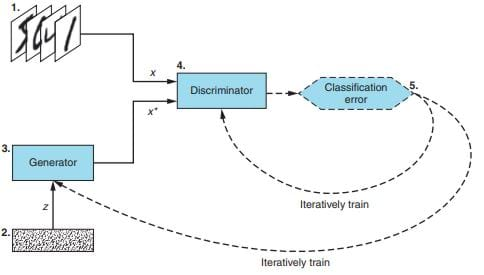

## 1. Import packages

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import os
import os.path as osp

# pytorch packages
import torch
import torch.nn as nn
from torch.autograd import Variable
import torchvision
import torchvision.datasets as dsets
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import torch.nn.functional as F

from tqdm.auto import tqdm


## 2. Data loading and preprocessing

In [ ]:

data_root = './data'
datasets = dsets.MNIST(root = data_root, download=True,
                      transform = transforms.Compose([
                          transforms.ToTensor(),
                          transforms.Normalize([0.5],[0.5])
                      ]),
                      train = True)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:02<00:00, 4.56MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:06<00:00, 243kB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 8.26MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



**Show the MNIST sample images**

torch.Size([1, 28, 28])


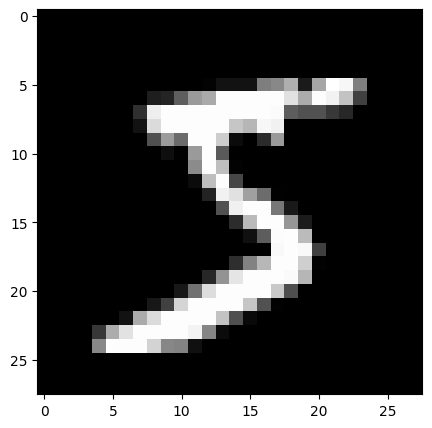

In [ ]:
a = datasets[0][0]

def show(img):
    """Given the image tensor, show the gray image.
    """
    img = img.view(28,28)
    plt.figure(figsize=(5,5))
    plt.imshow(img,cmap = 'gray')
    plt.show()
    return

def show_grid(images, title = None, rows = 4):
    """Given the images tensors, show the multiple images
    """
    num = images.size(0)

    fig = plt.figure(figsize= (5,5))
    plt.title(title)
    cols = int(num/rows)

    for i in range(1, num+1):
        img = images[i-1].view(28,28)
        fig.add_subplot(rows, cols, i)
        plt.axis('off')
        plt.imshow(img, cmap = 'gray')

    plt.show()
    return

print(a.size())
show(a)



**Make the dataset iterable**

In [ ]:
batch_size = 100
data_loader = torch.utils.data.DataLoader(dataset = datasets,
                                         batch_size = batch_size ,
                                         shuffle = True)

num_batches = int(len(datasets)/batch_size)
print('Batch size :{}, number of batches in one epoch :{}'.format(batch_size, num_batches))


Batch size :100, number of batches in one epoch :600


## 3. Build Network Class

**Build the discriminator network, 3 layers**

In [ ]:
### Build the discriminator network
class Dis(nn.Module):

    def __init__(self):
        super(Dis,self ).__init__()

        self.layer1 = nn.Sequential(
            nn.Linear(784, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)
        )

        self.layer2 = nn.Sequential(
            nn.Linear(1024,512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)
        )

        self.layer3 = nn.Sequential(
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)
        )

        self.layer_out = nn.Linear(256,1)

    def forward(self, x):

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = F.sigmoid(self.layer_out(x))

        return x



**Build the generator network**

In [ ]:
### Build the generator network
class Gen(nn.Module):

    def __init__(self):
        super(Gen,self).__init__()

        self.num_features = 100

        self.layer1 = nn.Sequential(
            nn.Linear(self.num_features, 256),
            nn.LeakyReLU(0.2)
        )

        self.layer2 = nn.Sequential(
            nn.Linear(256,512),
            nn.LeakyReLU(0.2)
        )

        self.layer3 = nn.Sequential(
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2)

        )

        self.layer_out = nn.Sequential(
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, x):

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer_out(x)

        return x

**Instantiate the model class**  
**Put the models to GPU if CUDA is available**

In [ ]:
### Instantiate the model class
Dis_model = Dis()
Gen_model = Gen()

### Put the model to the gpu if possible
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

if torch.cuda.device_count() > 1:
    Dis_model = nn.DataParallel(Dis_model).cuda()
    Gen_model = nn.DataParallel(Gen_model).cuda()

    torch.backends.cudnn.benchmark = True

Dis_model.to(device)
Gen_model.to(device)

print('The structure of discriminator:\n',Dis_model, '\nThe structure of generator:\n',Gen_model)

The structure of discriminator:
 Dis(
  (layer1): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
  )
  (layer2): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
  )
  (layer3): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
  )
  (layer_out): Linear(in_features=256, out_features=1, bias=True)
) 
The structure of generator:
 Gen(
  (layer1): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
  )
  (layer2): Sequential(
    (0): Linear(in_features=256, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
  )
  (layer3): Sequential(
    (0): Linear(in_features=512, out_features=1024, bias=True)
    (1):

## 4. Loss and optimizer

In [ ]:
dis_optimizer = torch.optim.Adam(Dis_model.parameters(), lr = 0.0002)
gen_optimizer = torch.optim.Adam(Gen_model.parameters(), lr = 0.0002)

criterion = nn.BCELoss()




## 5. Train the model

**Helper functions to generate real data and fake data labels**

In [ ]:
def real_label(real_data):
    """Generate real data labels
    """
    num = real_data.size(0)
    labels = Variable(torch.ones(num,1)).to(device)

    return labels

def fake_label(fake_data):
    """Generate fake data labels
    """
    num = fake_data.size(0)
    labels = Variable(torch.zeros(num,1)).to(device)

    return labels

**Helper functions to train the discriminator and generator**

In [ ]:


def train_dis(model,optimizer, real_data, fake_data):

    optimizer.zero_grad()

    # train on real data
    real_preds = model(real_data)
    loss_real = criterion(real_preds, real_label(real_data))
    loss_real.backward()

    # train on fake data
    fake_preds = model(fake_data)
    loss_fake = criterion(fake_preds, fake_label(fake_data))
    loss_fake.backward()

    loss_D = loss_real + loss_fake
    # update
    optimizer.step()

    return loss_D, real_preds, fake_preds

def train_gen(model, optimizer, fake_data):

    # reset optimizer
    optimizer.zero_grad()

    # sample noise and generate fake_data
    preds = model(fake_data)

    loss = criterion(preds, real_label(preds))
    loss.backward()

    optimizer.step()
    return loss,preds



**Generate samples for training**

In [ ]:
def noise(size):
    n = Variable(torch.randn(size, 100)).to(device)
    return n

num_test_samples = 16
test_noise = noise(num_test_samples)


**Start training**  
**Show the generated images every 20 epochs**

  0%|          | 0/100 [00:00<?, ?it/s]

epoch:0, iters:599, loss_D:0.7208293676376343, loss_G:2.576212167739868
D(x):0.8023812770843506, D(G(z1)):0.2812823951244354, D(G(z2):0.11537341773509979)


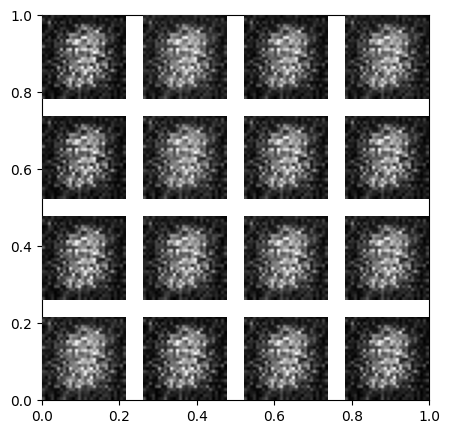

epoch:1, iters:1199, loss_D:1.2353651523590088, loss_G:1.4138813018798828
D(x):0.6500694751739502, D(G(z1)):0.4593587815761566, D(G(z2):0.30791833996772766)
epoch:2, iters:1799, loss_D:0.6068502068519592, loss_G:1.8045034408569336
D(x):0.7992908954620361, D(G(z1)):0.25407874584198, D(G(z2):0.22488167881965637)
epoch:3, iters:2399, loss_D:0.859631359577179, loss_G:1.8343126773834229
D(x):0.7559526562690735, D(G(z1)):0.26860156655311584, D(G(z2):0.22719290852546692)
epoch:4, iters:2999, loss_D:0.2911494970321655, loss_G:2.854173421859741
D(x):0.9036083221435547, D(G(z1)):0.10856147855520248, D(G(z2):0.0903385728597641)
epoch:5, iters:3599, loss_D:0.4396258592605591, loss_G:3.4862475395202637
D(x):0.8593680262565613, D(G(z1)):0.13023178279399872, D(G(z2):0.08435703068971634)
epoch:6, iters:4199, loss_D:0.6907602548599243, loss_G:1.8491637706756592
D(x):0.7535642981529236, D(G(z1)):0.20440852642059326, D(G(z2):0.21334171295166016)
epoch:7, iters:4799, loss_D:0.9259881377220154, loss_G:1.73

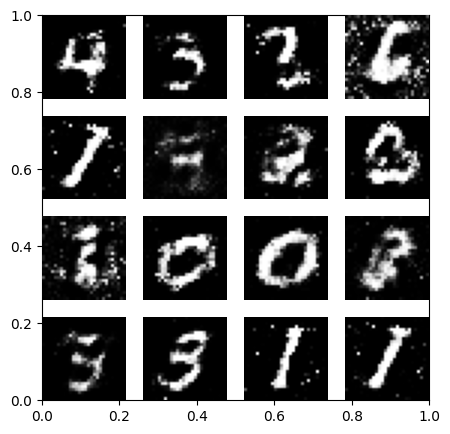

epoch:26, iters:16199, loss_D:0.922068178653717, loss_G:1.4114696979522705
D(x):0.7155026197433472, D(G(z1)):0.32737967371940613, D(G(z2):0.307090699672699)
epoch:27, iters:16799, loss_D:0.8810375928878784, loss_G:1.322600245475769
D(x):0.752604067325592, D(G(z1)):0.36249876022338867, D(G(z2):0.3431859612464905)
epoch:28, iters:17399, loss_D:1.103063702583313, loss_G:1.262373447418213
D(x):0.6515375971794128, D(G(z1)):0.3798634111881256, D(G(z2):0.32774993777275085)
epoch:29, iters:17999, loss_D:1.1893064975738525, loss_G:1.0287179946899414
D(x):0.6533674597740173, D(G(z1)):0.41896751523017883, D(G(z2):0.40402066707611084)
epoch:30, iters:18599, loss_D:1.0188075304031372, loss_G:1.5154920816421509
D(x):0.683255136013031, D(G(z1)):0.3518543839454651, D(G(z2):0.288328617811203)
epoch:31, iters:19199, loss_D:1.0947015285491943, loss_G:1.3069671392440796
D(x):0.6874957084655762, D(G(z1)):0.3697109520435333, D(G(z2):0.35592612624168396)
epoch:32, iters:19799, loss_D:1.1007304191589355, loss

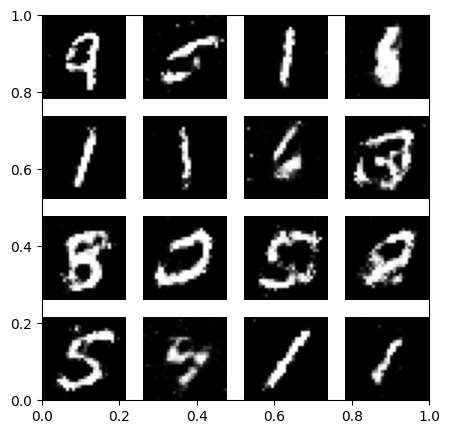

epoch:51, iters:31199, loss_D:0.9922677278518677, loss_G:1.2533704042434692
D(x):0.6225335597991943, D(G(z1)):0.337301641702652, D(G(z2):0.32088154554367065)
epoch:52, iters:31799, loss_D:1.2365669012069702, loss_G:1.0015751123428345
D(x):0.6045464277267456, D(G(z1)):0.4450180232524872, D(G(z2):0.4034474194049835)
epoch:53, iters:32399, loss_D:1.3327739238739014, loss_G:0.9324601292610168
D(x):0.5596824288368225, D(G(z1)):0.44125473499298096, D(G(z2):0.44197267293930054)
epoch:54, iters:32999, loss_D:1.2006933689117432, loss_G:0.8708437085151672
D(x):0.5788114666938782, D(G(z1)):0.4111308455467224, D(G(z2):0.46206384897232056)
epoch:55, iters:33599, loss_D:1.2195651531219482, loss_G:1.0024032592773438
D(x):0.5669003129005432, D(G(z1)):0.39745038747787476, D(G(z2):0.40890175104141235)
epoch:56, iters:34199, loss_D:1.277685284614563, loss_G:1.055748701095581
D(x):0.5553851127624512, D(G(z1)):0.41463804244995117, D(G(z2):0.3952276408672333)
epoch:57, iters:34799, loss_D:1.1503851413726807

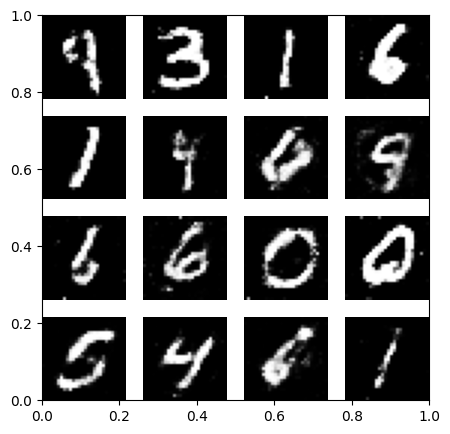

epoch:76, iters:46199, loss_D:1.0819849967956543, loss_G:0.9111431837081909
D(x):0.6490048170089722, D(G(z1)):0.4087643623352051, D(G(z2):0.42960309982299805)
epoch:77, iters:46799, loss_D:1.1742866039276123, loss_G:1.0294033288955688
D(x):0.589393675327301, D(G(z1)):0.4279010593891144, D(G(z2):0.39296263456344604)
epoch:78, iters:47399, loss_D:1.2964584827423096, loss_G:0.8325005173683167
D(x):0.5752230882644653, D(G(z1)):0.4537336528301239, D(G(z2):0.46438995003700256)
epoch:79, iters:47999, loss_D:1.345242977142334, loss_G:0.7966674566268921
D(x):0.5420137047767639, D(G(z1)):0.4774092137813568, D(G(z2):0.47738340497016907)
epoch:80, iters:48599, loss_D:1.2521252632141113, loss_G:0.9665427803993225
D(x):0.5764878988265991, D(G(z1)):0.43706732988357544, D(G(z2):0.4114544987678528)
epoch:81, iters:49199, loss_D:1.192833423614502, loss_G:1.0746952295303345
D(x):0.5454760789871216, D(G(z1)):0.36553633213043213, D(G(z2):0.3948976695537567)
epoch:82, iters:49799, loss_D:1.2388901710510254,

In [ ]:
num_epochs = 100

for epoch in tqdm(range(num_epochs)):

    for batch_idx, (real_images, _) in enumerate(data_loader):

        ### 1. Train the discriminator
        real_images = Variable(real_images.view(-1,28*28)).to(device)

        #generate the fake data
        fake_images = Gen_model(noise(real_images.size(0))).detach()

        # train the discriminator
        loss_D, real_preds, fake_preds = train_dis(Dis_model, dis_optimizer, real_images, fake_images)

        D_x = real_preds.mean().item()
        D_G1 = fake_preds.mean().item()

        ### 2. Train the generator
        fake_images = Gen_model(noise(real_images.size(0)))
        # train the generator
        loss_G, preds = train_gen(Dis_model, gen_optimizer, fake_images)

        D_G2 = preds.mean().item()

    # show the loss every epoch
    print('epoch:{}, iters:{}, loss_D:{}, loss_G:{}'.format(epoch, batch_idx +epoch*num_batches , loss_D.item(), loss_G.item()))
    print('D(x):{}, D(G(z1)):{}, D(G(z2):{})'.format(D_x, D_G1, D_G2))

    # show the test images every 25 epochs
    if epoch%25 ==0:
        test_imgs = Gen_model(test_noise).cpu().detach()
        show_grid(test_imgs)


torch.Size([784])


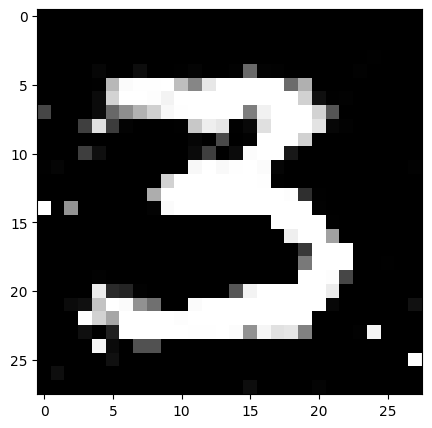

In [ ]:
test_imgs = Gen_model(test_noise).cpu().detach()

# a = test_imgs[7].cpu().detach()
a = test_imgs[1]
print(a.size())
show(a)

torch.Size([784])


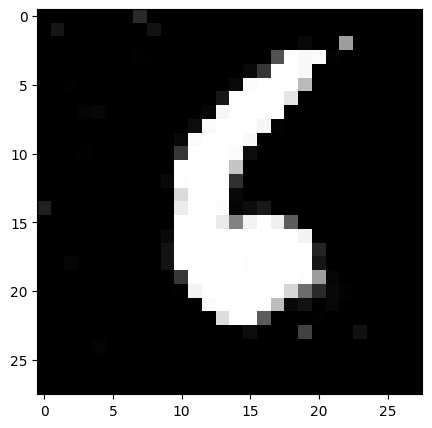

In [ ]:


test_imgs = Gen_model(test_noise).cpu().detach()

# a = test_imgs[7].cpu().detach()
a = test_imgs[3]
print(a.size())
show(a)